In [1]:
!pip install pandas scikit-learn nltk matplotlib

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, GaussianNB, BernoulliNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import time

nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

True

In [3]:
file_path = 'News_Category_Dataset_v3.json'
df = pd.read_json('/content/News_Category_Dataset_v3.json', lines=True)
df['text'] = df['headline'] + " " + df['short_description']
df = df[['category', 'text']]

###Visualization of dataset
Issue #1

In [4]:
counts = df['category'].value_counts()
X_plot = counts.index.tolist()
Y_plot = counts.values.tolist()

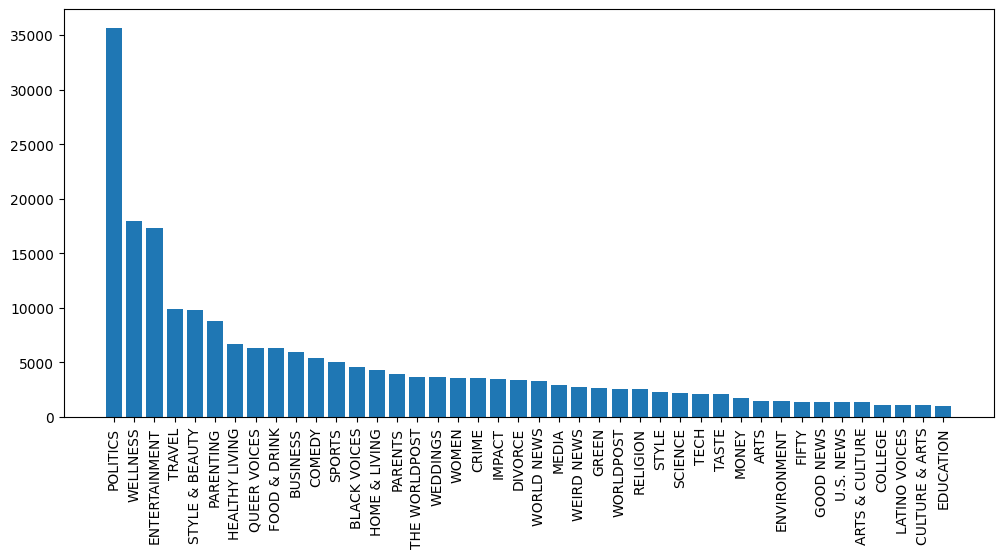

In [5]:
plt.figure(figsize=(12,6))
plt.bar(X_plot,Y_plot)
plt.xticks(rotation=90)
plt.subplots_adjust(bottom=0.2)

In [7]:
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    lemmatizer = WordNetLemmatizer()
    tokens = word_tokenize(text.lower())
    tokens = [token for token in tokens if token.isalpha() and token not in stop_words]
    return ' '.join(tokens)

df['processed_text'] = df['text'].apply(preprocess_text)

###Splitting data set
Issue #4

In [8]:
X_train, X_test, y_train, y_test = train_test_split(df['processed_text'], df['category'], test_size=0.2,random_state=True)

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000)),
    ('classifier', BernoulliNB()),
])

###Training & Testing

In [9]:
print("Training the model...")
start_time = time.time()
pipeline.fit(X_train, y_train)
end_time = time.time()
training_time = end_time - start_time
print(f"Training completed in {training_time:.2f} seconds ({training_time/60:.2f} minutes)")

print("Making predictions...")
y_pred = pipeline.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=1))

Training the model...
Training completed in 6.67 seconds (0.11 minutes)
Making predictions...
Accuracy: 0.5427

Classification Report:
                precision    recall  f1-score   support

          ARTS       0.23      0.18      0.20       284
ARTS & CULTURE       0.33      0.15      0.21       267
  BLACK VOICES       0.40      0.29      0.34       892
      BUSINESS       0.43      0.41      0.42      1199
       COLLEGE       0.42      0.26      0.33       234
        COMEDY       0.43      0.44      0.44      1077
         CRIME       0.40      0.69      0.51       720
CULTURE & ARTS       0.37      0.21      0.27       203
       DIVORCE       0.71      0.66      0.68       688
     EDUCATION       0.35      0.34      0.35       191
 ENTERTAINMENT       0.49      0.69      0.58      3435
   ENVIRONMENT       0.50      0.19      0.28       308
         FIFTY       0.14      0.15      0.14       244
  FOOD & DRINK       0.50      0.74      0.59      1294
     GOOD NEWS       0.2

###Confusion Matrix
Issue #6


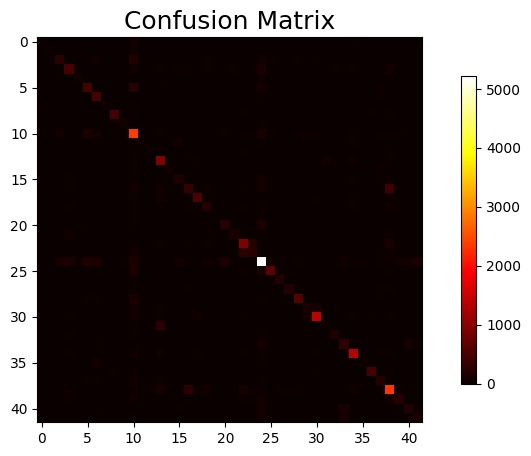

In [10]:
plt.figure(figsize=(10, 5))
plt.imshow(confusion_matrix(y_test, y_pred), interpolation='nearest', cmap='hot')
plt.title('Confusion Matrix', fontsize=18)
plt.colorbar(shrink=0.8)
plt.show()